# 2D Linear Elasticity — Strong Formulation

Solve the **linear elasticity** equations on the unit square using a Physics-Informed Neural Network.

## Problem statement

Find $\mathbf{u} : \Omega \to \mathbb{R}^2$ such that

$$\nabla \cdot \boldsymbol{\sigma} = \mathbf{0} \quad \text{in } \Omega = [0,1]^2$$

with constitutive law (isotropic linear elasticity):

$$\sigma_{ij} = \lambda \, u_{k,k} \, \delta_{ij} + \mu \left( u_{i,j} + u_{j,i} \right)$$

**Boundary conditions:**

| Boundary | Condition | Description |
|---|---|---|
| Left ($x=0$) | $u_1 = 0,\; u_2 = 0$ | Clamped wall — zero displacement |
| Right ($x=1$) | $\boldsymbol{\sigma}\cdot\mathbf{n} = (0.5,\, 0)$ | Applied traction in $x$ |
| Top & bottom | $\boldsymbol{\sigma}\cdot\mathbf{n} = \mathbf{0}$ | Traction-free |

**Lamé parameters:** $\lambda = \mu = 1$.

## Strong-form PDE

$$r_1 = (\lambda+2\mu)\,u_{1,xx} + \mu\,u_{1,yy} + (\lambda+\mu)\,u_{2,xy} = 0$$
$$r_2 = (\lambda+\mu)\,u_{1,xy} + \mu\,u_{2,xx} + (\lambda+2\mu)\,u_{2,yy} = 0$$

The traction and traction-free conditions are enforced as **custom residual BCs** via
`domain.add_bc(edges, f, name)`, where `f` returns the stress residuals directly.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "pinn_models"))

import pinns
pinns.use_backend("jax")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import jax
import jax.numpy as jnp

print("JAX backend:", jax.default_backend())
print("Available devices:", jax.devices())

pinns: Using jax backend
JAX backend: gpu
Available devices: [CudaDevice(id=0)]


## 1. Mesh

Triangulate the unit square with `pygmsh`. We label the four boundary edges so the trainer
can assign separate boundary-condition loss weights to each side.

In [2]:
import pygmsh

mesh_size = 0.05   # decrease for a finer mesh

with pygmsh.geo.Geometry() as geom:
    p0 = geom.add_point([0.0, 0.0, 0.0], mesh_size=mesh_size)
    p1 = geom.add_point([1.0, 0.0, 0.0], mesh_size=mesh_size)
    p2 = geom.add_point([1.0, 1.0, 0.0], mesh_size=mesh_size)
    p3 = geom.add_point([0.0, 1.0, 0.0], mesh_size=mesh_size)

    l_bottom = geom.add_line(p0, p1)
    l_right  = geom.add_line(p1, p2)
    l_top    = geom.add_line(p2, p3)
    l_left   = geom.add_line(p3, p0)

    loop    = geom.add_curve_loop([l_bottom, l_right, l_top, l_left])
    surface = geom.add_plane_surface(loop)

    geom.add_physical(l_bottom, "bottom")
    geom.add_physical(l_right,  "right")
    geom.add_physical(l_top,    "top")
    geom.add_physical(l_left,   "left")
    geom.add_physical(surface,  "interior")

    mesh = geom.generate_mesh(dim=2, verbose=False)

verts = mesh.points[:, :2]
faces = mesh.cells_dict["triangle"]
print(f"Mesh: {len(verts)} vertices, {len(faces)} triangles")

def boundary_edges(mesh, name):
    if name in mesh.cell_sets_dict:
        for cell_type, block_indices in mesh.cell_sets_dict[name].items():
            if "line" in cell_type:
                cells = mesh.cells_dict.get(cell_type)
                if cells is not None:
                    return cells[block_indices]
    raise KeyError(f"Physical group '{name}' not found.")


edges_bottom = boundary_edges(mesh, "bottom")
edges_right  = boundary_edges(mesh, "right")
edges_top    = boundary_edges(mesh, "top")
edges_left   = boundary_edges(mesh, "left")

Mesh: 513 vertices, 944 triangles


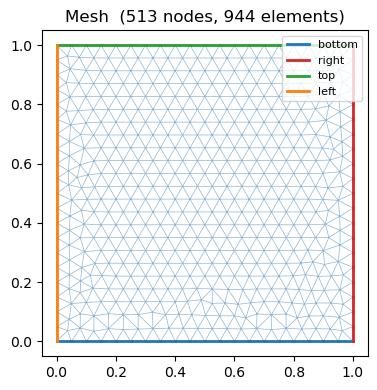

In [3]:
# ── Quick mesh plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
tri_plot = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_plot, color='steelblue', lw=0.5, alpha=0.6)

colors = {'bottom': 'tab:blue', 'right': 'tab:red', 'top': 'tab:green', 'left': 'tab:orange'}
for bname, bedges in zip(['bottom', 'right', 'top', 'left'],
                         [edges_bottom, edges_right, edges_top, edges_left]):
    v0, v1 = bedges[:, 0], bedges[:, 1]
    for i in range(len(v0)):
        ax.plot([verts[v0[i], 0], verts[v1[i], 0]],
                [verts[v0[i], 1], verts[v1[i], 1]],
                color=colors[bname], lw=2,
                label=bname if i == 0 else None)

ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal')
ax.set_title(f'Mesh  ({len(verts)} nodes, {len(faces)} elements)')
plt.tight_layout()
plt.show()

## 2. Domain and boundary conditions

We set the following physical BCs on the unit square:

| Edge | Condition | Type |
|---|---|---|
| Left ($x=0$) | $u_1=0,\; u_2=0$ — clamped wall | Dirichlet |
| Right ($x=1$, $\mathbf{n}=(1,0)$) | $\boldsymbol{\sigma}\cdot\mathbf{n}=(0.5,\,0)$ — applied traction | Custom residual |
| Top & bottom ($\mathbf{n}=(0,\pm1)$) | $\boldsymbol{\sigma}\cdot\mathbf{n}=\mathbf{0}$ — traction-free | Custom residual |

There is no closed-form analytical solution for this setup.

Custom residual BCs use `domain.add_bc(edges, f, name)` where `f` has the same
signature as `pde_fn` and returns the residual(s) to minimise:

```python
def traction_right(x, y, params, derivative):
    ...
    return sigma_11 - 0.5, sigma_12   # σ·n = (0.5, 0)

domain.add_bc(edges_right, f=traction_right, name="right_traction")
```


In [4]:
domain = pinns.DomainMesh(mesh)

# ── Left edge (x = 0) — clamped: u1 = 0, u2 = 0 ─────────────────────────────
domain.add_dirichlet(edges_left, value=0.0, component=0, name="left_u1")
domain.add_dirichlet(edges_left, value=0.0, component=1, name="left_u2")

# ── Right edge (x = 1) — traction σ·n = (0.5, 0), n=(1,0) ───────────────────
# σ₁₁ = (λ+2μ)∂ₓu₁ + λ∂ᵧu₂ = 0.5
# σ₁₂ = μ(∂ᵧu₁ + ∂ₓu₂) = 0
def traction_right(x, y, params, derivative):
    lam = params['fixed']['lam']
    mu  = params['fixed']['mu']
    u1_x = derivative(y, x, 0, (0,))
    u2_y = derivative(y, x, 1, (1,))
    u1_y = derivative(y, x, 0, (1,))
    u2_x = derivative(y, x, 1, (0,))
    sigma_11 = (lam + 2*mu) * u1_x + lam * u2_y
    sigma_12 = mu * (u1_y + u2_x)
    return sigma_11 - 0.5, sigma_12

domain.add_bc(edges_right, f=traction_right, name=["right_normal", "right_shear"])

# ── Top edge (y = 1) — traction-free: σ·n = 0, n=(0,1) ──────────────────────
# σ₂₁ = μ(∂ᵧu₁ + ∂ₓu₂) = 0
# σ₂₂ = λ∂ₓu₁ + (λ+2μ)∂ᵧu₂ = 0
def traction_free_top(x, y, params, derivative):
    lam = params['fixed']['lam']
    mu  = params['fixed']['mu']
    u1_x = derivative(y, x, 0, (0,))
    u2_y = derivative(y, x, 1, (1,))
    u1_y = derivative(y, x, 0, (1,))
    u2_x = derivative(y, x, 1, (0,))
    sigma_21 = mu * (u1_y + u2_x)
    sigma_22 = lam * u1_x + (lam + 2*mu) * u2_y
    return sigma_21, sigma_22

domain.add_bc(edges_top, f=traction_free_top, name=["top_shear", "top_normal"])

# ── Bottom edge (y = 0) — traction-free: σ·n = 0, n=(0,-1) ──────────────────
# same stress components (residuals are the same: σ₂₁=0, σ₂₂=0)
def traction_free_bottom(x, y, params, derivative):
    lam = params['fixed']['lam']
    mu  = params['fixed']['mu']
    u1_x = derivative(y, x, 0, (0,))
    u2_y = derivative(y, x, 1, (1,))
    u1_y = derivative(y, x, 0, (1,))
    u2_x = derivative(y, x, 1, (0,))
    sigma_21 = mu * (u1_y + u2_x)
    sigma_22 = lam * u1_x + (lam + 2*mu) * u2_y
    return sigma_21, sigma_22

domain.add_bc(edges_bottom, f=traction_free_bottom, name=["bottom_shear", "bottom_normal"])

print(f"Boundary conditions added: {len(domain.boundary_conditions)}")
for bc in domain.boundary_conditions:
    bc_type = getattr(bc, 'bc_type', 'custom')
    print(f"  {bc.name:18s}  type={bc_type}")


Boundary conditions added: 8
  left_u1             type=dirichlet
  left_u2             type=dirichlet
  right_normal        type=custom
  right_shear         type=custom
  top_shear           type=custom
  top_normal          type=custom
  bottom_shear        type=custom
  bottom_normal       type=custom


## 3. PDE function and observables

The network predicts $\mathbf{u} = (u_1, u_2)$.  The four-argument `pde_fn` returns the two equilibrium residuals as a tuple `(r1, r2)`.

`Problem` also accepts an `obs_fn` + `obs_names` pair.  `obs_fn` has the **same signature as `pde_fn`** and returns a **list** of derived scalar fields — one per name — evaluated and **plotted alongside the solution** at every progress update.

### Deformed-mesh visualisation — `obs_spatial`

If some observables represent the **absolute new spatial positions** of nodes (e.g. $x + u_1$, $y + u_2$), pass their names in `obs_spatial`.  Two side-by-side panels are shown: the **original mesh** on the left and the **deformed mesh** on the right, coloured by $\|\mathbf{u}\|$:

```python
problem = pinns.Problem(
    ...,
    obs_fn=obs_fn,
    obs_names=["sigma_11", "sigma_12", "sigma_22", "x_deformed", "y_deformed"],
    obs_spatial=["x_deformed", "y_deformed"],   # absolute new positions
)
```

Here we compute the three independent Cauchy stress components and the deformed coordinates:

$$\sigma_{11} = (\lambda+2\mu)\,\partial_x u_1 + \lambda\,\partial_y u_2 \quad [\text{exact} = 0.5]$$
$$\sigma_{12} = \mu\,(\partial_y u_1 + \partial_x u_2) \quad [\text{exact} = 0]$$
$$\sigma_{22} = \lambda\,\partial_x u_1 + (\lambda+2\mu)\,\partial_y u_2 \quad [\text{exact} = 0]$$
$$x_\text{def} = x + u_1, \quad y_\text{def} = y + u_2$$


In [5]:
def pde_fn(x, y, params, derivative):
    """
    Equilibrium equations for isotropic linear elasticity (no body force).

      r1 = (λ+2μ) u1_xx + μ u1_yy + (λ+μ) u2_xy = 0
      r2 = (λ+μ)  u1_xy + μ u2_xx + (λ+2μ) u2_yy = 0
    """
    lam = params['fixed']['lam']
    mu  = params['fixed']['mu']

    u1_xx = derivative(y, x, 0, (0, 0))
    u1_yy = derivative(y, x, 0, (1, 1))
    u1_xy = derivative(y, x, 0, (0, 1))
    u2_xx = derivative(y, x, 1, (0, 0))
    u2_yy = derivative(y, x, 1, (1, 1))
    u2_xy = derivative(y, x, 1, (0, 1))

    r1 = (lam + 2*mu) * u1_xx + mu * u1_yy + (lam + mu) * u2_xy
    r2 = (lam + mu)   * u1_xy + mu * u2_xx + (lam + 2*mu) * u2_yy
    return r1, r2


# ── Stress and deformation observables ───────────────────────────────────────
# Cauchy stress components + deformed coordinates (shown as deformed-mesh plot)
def obs_fn(x, y, params, derivative):
    lam = params['fixed']['lam']
    mu  = params['fixed']['mu']
    u1_x = derivative(y, x, 0, (0,))
    u1_y = derivative(y, x, 0, (1,))
    u2_x = derivative(y, x, 1, (0,))
    u2_y = derivative(y, x, 1, (1,))
    sigma_11 = (lam + 2*mu) * u1_x + lam * u2_y
    sigma_12 = mu * (u1_y + u2_x)
    sigma_22 = lam * u1_x + (lam + 2*mu) * u2_y
    # Deformed positions: x + u1, y + u2
    x_def = x[:, 0] + y[:, 0]
    y_def = x[:, 1] + y[:, 1]
    return [sigma_11, sigma_12, sigma_22, x_def, y_def]


# ── Problem ───────────────────────────────────────────────────────────────────
problem = pinns.Problem(
    domain=domain,
    pde_fn=pde_fn,
    input_names=["x", "y"],
    output_names=["u1", "u2"],
    params={"lam": 1.0, "mu": 1.0},
    obs_fn=obs_fn,
    obs_names=["sigma_11", "sigma_12", "sigma_22", "x_deformed", "y_deformed"],
    obs_spatial=["x_deformed", "y_deformed"],
)

print(problem)


Problem(domain=DomainMesh(2D, n_nodes=513, n_conditions=8), n_dims=2, n_outputs=2, n_boundary_conditions=8, params=['lam', 'mu'])


## 4. Training

The network maps $(x, y) \mapsto (u_1, u_2)$ with shared hidden layers.
Interior collocation points are sampled inside $\Omega$; boundary points come from
the four edge groups.

The Lamé parameter $\lambda = \mu = 1$ is a low-contrast situation (Poisson ratio
$\nu = \lambda / (2(\lambda+\mu)) = 0.25$).  A deeper network or longer training
helps when $\lambda \gg \mu$ (near-incompressible regime).

Starting training for 10000 epochs (JIT-compiled)...


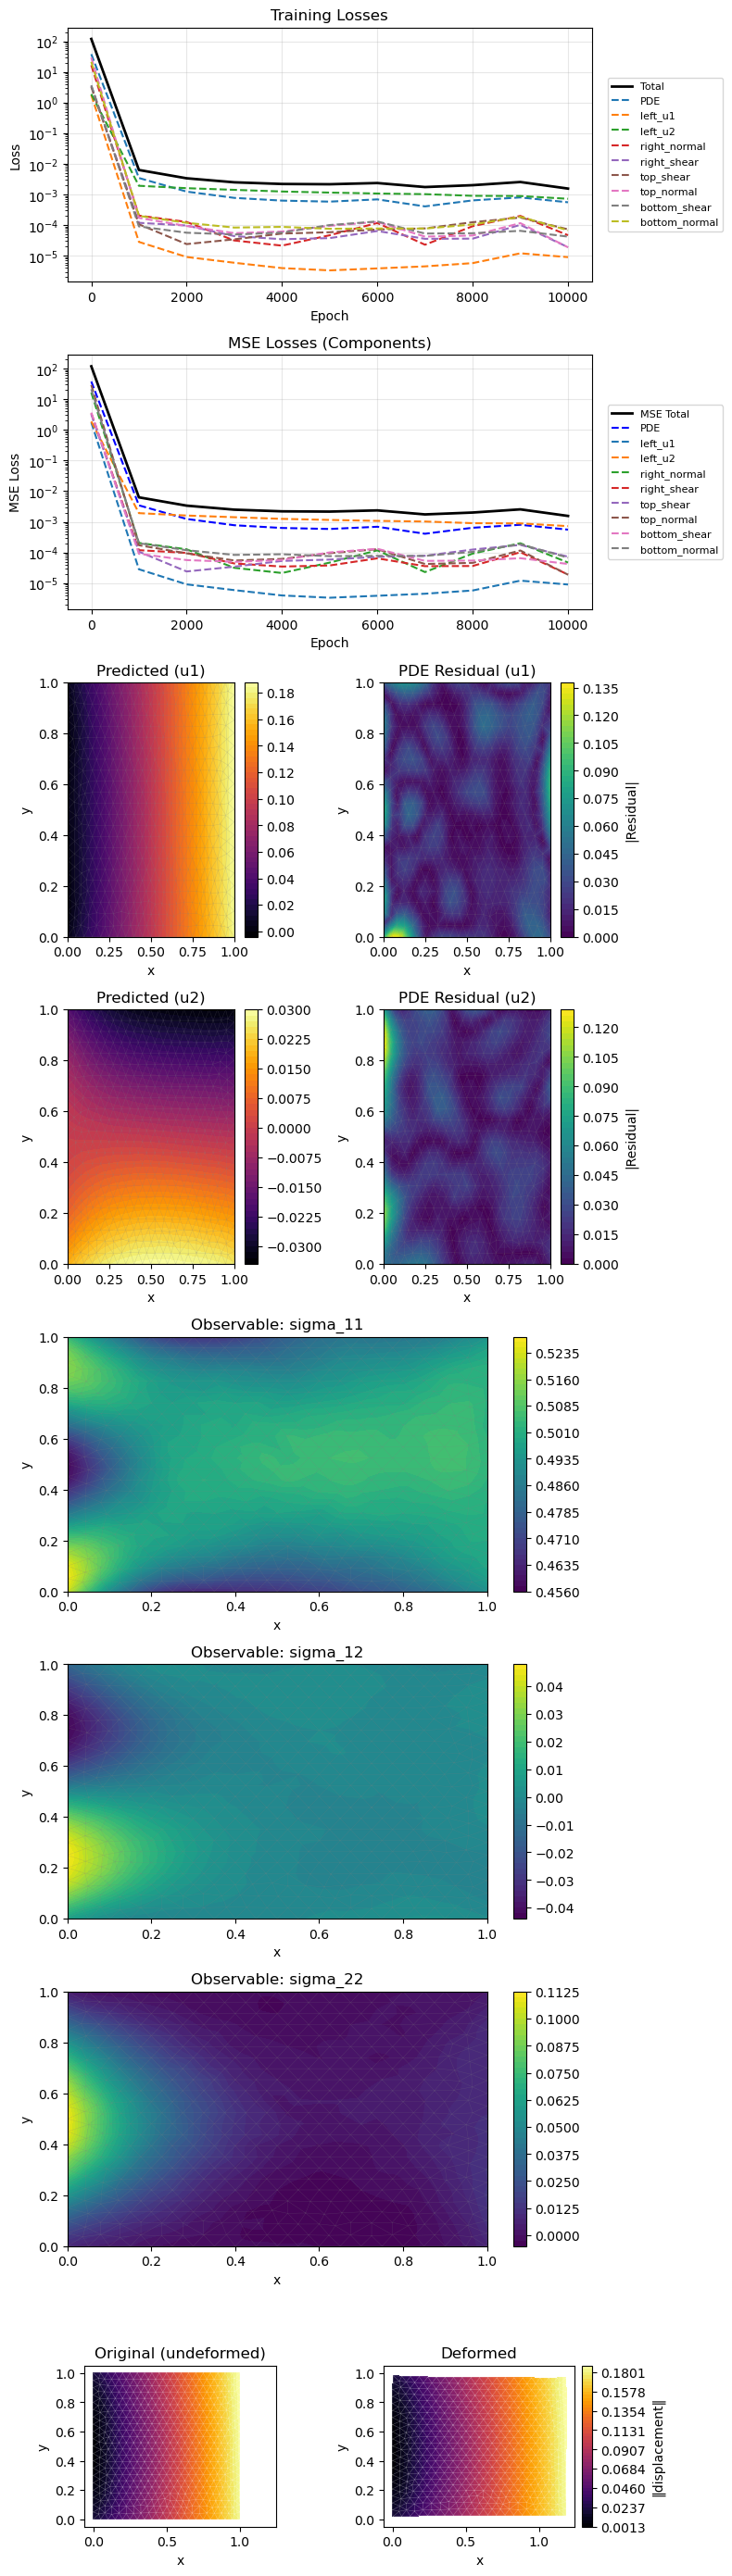

Epoch 0/10000 | Loss: 1.19e+02 | MSE Loss: 1.19e+02 | PDE: 3.78e+01 | BCs: [left_u1: 1.76e+00, left_u2: 1.88e+00, right_normal: 1.65e+01, right_shear: 3.47e+00, top_shear: 3.23e+00, top_normal: 2.91e+01, bottom_shear: 3.65e+00, bottom_normal: 2.12e+01] | Time: 0.0s
Epoch 1000/10000 | Loss: 6.30e-03 | MSE Loss: 6.30e-03 | PDE: 3.45e-03 | BCs: [left_u1: 2.84e-05, left_u2: 1.92e-03, right_normal: 2.05e-04, right_shear: 1.19e-04, top_shear: 1.06e-04, top_normal: 1.72e-04, bottom_shear: 9.09e-05, bottom_normal: 2.01e-04] | Time: 5.3s
Epoch 2000/10000 | Loss: 3.38e-03 | MSE Loss: 3.38e-03 | PDE: 1.24e-03 | BCs: [left_u1: 9.14e-06, left_u2: 1.61e-03, right_normal: 1.27e-04, right_shear: 9.71e-05, top_shear: 2.41e-05, top_normal: 9.38e-05, bottom_shear: 5.66e-05, bottom_normal: 1.19e-04] | Time: 7.6s
Epoch 3000/10000 | Loss: 2.50e-03 | MSE Loss: 2.50e-03 | PDE: 7.75e-04 | BCs: [left_u1: 5.93e-06, left_u2: 1.42e-03, right_normal: 3.16e-05, right_shear: 4.39e-05, top_shear: 3.45e-05, top_normal:

In [10]:
network = pinns.FNN([2, 64, 64, 64, 2], activation="tanh")

trainer = pinns.Trainer(problem, network)
trainer.compile(
    train_samples={
        "pde":           800,
        "left_u1":        50,
        "left_u2":        50,
        "right_normal":   50,
        "right_shear":    50,
        "top_shear":      50,
        "top_normal":     50,
        "bottom_shear":   50,
        "bottom_normal":  50,
    },
    weights={
        "pde":           1.0,
        "left_u1":       10.0,
        "left_u2":       10.0,
        "right_normal":  10.0,
        "right_shear":   10.0,
        "top_shear":     10.0,
        "top_normal":    10.0,
        "bottom_shear":  10.0,
        "bottom_normal": 10.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=1000,
    show_plots=True,
)
trainer.train()


# 2D Linear Elasticity — Weak Formulation

Instead of enforcing the PDE pointwise (strong form), the **weak / Galerkin form** multiplies
each equilibrium equation by a test function $\phi$ and integrates by parts over $\Omega$:

$$\int_\Omega \left(\sigma_{11}\,\frac{\partial\phi}{\partial x} + \sigma_{12}\,\frac{\partial\phi}{\partial y}\right) d\Omega = \int_{\Gamma_R} t_1\,\phi\,dS$$

$$\int_\Omega \left(\sigma_{12}\,\frac{\partial\phi}{\partial x} + \sigma_{22}\,\frac{\partial\phi}{\partial y}\right) d\Omega = \int_{\Gamma_R} t_2\,\phi\,dS$$

`ProblemWeak` uses finite-element mesh cubature to assemble the residual vectors $\mathbf{R}_1$
and $\mathbf{R}_2$ (one entry per free node per equation) and minimises $\|\mathbf{R}_1\|^2 + \|\mathbf{R}_2\|^2$.

**Boundary conditions** match the strong form exactly:

| Edge | Condition | Treatment |
|---|---|---|
| Left ($x=0$) | $u_1=0,\; u_2=0$ | Dirichlet — nodes removed from residual |
| Right ($x=1$) | $\boldsymbol{\sigma}\cdot\mathbf{n}=(0.5,\,0)$ | **Weak BC** — `f(x,y,params,phi,derivative)` returns RHS line-integral integrands |
| Top & bottom | $\boldsymbol{\sigma}\cdot\mathbf{n}=\mathbf{0}$ | Natural — boundary integral vanishes, no treatment needed |

### Weak vs strong boundary functions

`domain.add_bc` detects the BC type from the function signature:

| Signature | Type | Behaviour |
|---|---|---|
| `f(x, y, params, derivative)` | **Strong** pointwise | Minimised as $\text{mean}(f^2)$ by the trainer |
| `f(x, y, params, phi, derivative)` | **Weak** line-integral | Integrated as $\int_\Gamma f\,dS$ and subtracted from $\mathbf{R}$ |

Traction-free edges (top and bottom) need no `add_bc` call at all — they contribute zero to the
Neumann boundary integral and are automatically handled as natural BCs.


In [11]:
domain_w = pinns.DomainMesh(mesh)

# ── Left edge (x = 0) — clamped: u1 = 0, u2 = 0 ─────────────────────────────
# Dirichlet: nodes are removed from the residual vector entirely.
domain_w.add_dirichlet(edges_left, value=0.0, component=0, name="left_u1")
domain_w.add_dirichlet(edges_left, value=0.0, component=1, name="left_u2")

# ── Right edge (x = 1) — applied traction (σ·n) = (0.5, 0), n=(1,0) ──────────
# Weak Neumann BC: f accepts 'phi' → detected as a line-integral RHS.
# Returns a tuple of two integrands — one per equation:
#   right_normal_rhs:  ∫ 0.5·φ ds   →  R1 RHS  (traction t₁ = 0.5)
#   right_shear_rhs:   ∫ 0  ·φ ds   →  R2 RHS  (traction t₂ = 0)
def traction_right_weak(x, y, params, phi, derivative):
    return 0.5 * phi, jnp.zeros_like(phi)

domain_w.add_bc(edges_right, f=traction_right_weak, name=["right_normal_rhs", "right_shear_rhs"])

def top_weak(x, y, params, phi, derivative):
    return jnp.zeros_like(phi), jnp.zeros_like(phi)
domain_w.add_bc(edges_top, f=top_weak, name=["top_normal_rhs", "top_shear_rhs"])


def bottom_weak(x, y, params, phi, derivative):
    return jnp.zeros_like(phi), jnp.zeros_like(phi)
domain_w.add_bc(edges_bottom, f=bottom_weak, name=["bottom_normal_rhs", "bottom_shear_rhs"])

# ── Top and bottom edges — traction-free (natural BC) ────────────────────────
# In the weak form σ·n = 0 means ∫ t·φ ds = 0 — the boundary integral vanishes
# automatically.  No add_bc call is needed.

print(f"Boundary conditions added: {len(domain_w.boundary_conditions)}")
for bc in domain_w.boundary_conditions:
    bc_type = getattr(bc, 'bc_type', 'custom')
    is_weak = getattr(bc, 'is_weak', False)
    print(f"  {bc.name:22s}  type={bc_type}  weak={is_weak}")


Boundary conditions added: 8
  left_u1                 type=dirichlet  weak=False
  left_u2                 type=dirichlet  weak=False
  right_normal_rhs        type=custom  weak=True
  right_shear_rhs         type=custom  weak=True
  top_normal_rhs          type=custom  weak=True
  top_shear_rhs           type=custom  weak=True
  bottom_normal_rhs       type=custom  weak=True
  bottom_shear_rhs        type=custom  weak=True


In [12]:
def volume_fn(x, y, params, phi, grad_phi, derivative):
    """
    Weak-form integrands for 2D linear elasticity — TWO separate residuals.

    Returning a tuple (a1, a2) tells the assembler to build two independent
    residual vectors:
      R1_j = ∫ [σ₁₁ ∂φ_j/∂x  +  σ₁₂ ∂φ_j/∂y] dΩ   (tests eq. 1 with φ_j)
      R2_j = ∫ [σ₁₂ ∂φ_j/∂x  +  σ₂₂ ∂φ_j/∂y] dΩ   (tests eq. 2 with φ_j)

    Each R_k is zero iff equilibrium equation k is satisfied in the weak sense.
    Neumann RHS integrals (∫_Γ t_k φ ds) are subtracted automatically from any
    weak BC registered on domain_w (signatures containing 'phi').
    """
    lam = params['fixed']['lam']
    mu  = params['fixed']['mu']

    u1_x = derivative(y, x, 0, (0,))   # ∂u₁/∂x
    u1_y = derivative(y, x, 0, (1,))   # ∂u₁/∂y
    u2_x = derivative(y, x, 1, (0,))   # ∂u₂/∂x
    u2_y = derivative(y, x, 1, (1,))   # ∂u₂/∂y

    sigma_11 = (lam + 2*mu) * u1_x + lam * u2_y
    sigma_12 = mu * (u1_y + u2_x)
    sigma_22 = lam * u1_x + (lam + 2*mu) * u2_y

    dphi_dx = grad_phi[:, 0]
    dphi_dy = grad_phi[:, 1]

    a1 = sigma_11 * dphi_dx + sigma_12 * dphi_dy   # eq. 1
    a2 = sigma_12 * dphi_dx + sigma_22 * dphi_dy   # eq. 2

    return a1, a2

# ── ProblemWeak ───────────────────────────────────────────────────────────────
# No boundary_fn needed — traction_right_weak is auto-detected from domain_w
# because its signature contains 'phi'.
problem_w = pinns.ProblemWeak(
    domain=domain_w,
    volume_fn=volume_fn,
    input_names=["x", "y"],
    output_names=["u1", "u2"],
    params={"lam": 1.0, "mu": 1.0},
    cubature_order=3,
    obs_fn=obs_fn,
    obs_names=["sigma_11", "sigma_12", "sigma_22", "x_deformed", "y_deformed"],
    obs_spatial=["x_deformed", "y_deformed"],
)

print(problem_w)
print(f"\nWeak boundary integrals collected: {len(problem_w.boundary_fn_data)}")
for bd in problem_w.boundary_fn_data:
    print(f"  '{bd['name']}'  —  {bd['pts'].shape[0]} edges")

ProblemWeak(n_verts=513, n_dofs=513, n_faces=944, n_free=492, n_dirichlet=21, n_neumann_bcs=0, cubature_order=3, lagrange_order=1 (P1, 3 dofs/elem), basis='lagrange')

Weak boundary integrals collected: 3
  '['right_normal_rhs', 'right_shear_rhs']'  —  20 edges
  '['top_normal_rhs', 'top_shear_rhs']'  —  20 edges
  '['bottom_normal_rhs', 'bottom_shear_rhs']'  —  20 edges


Starting training for 10000 epochs (JIT-compiled)...


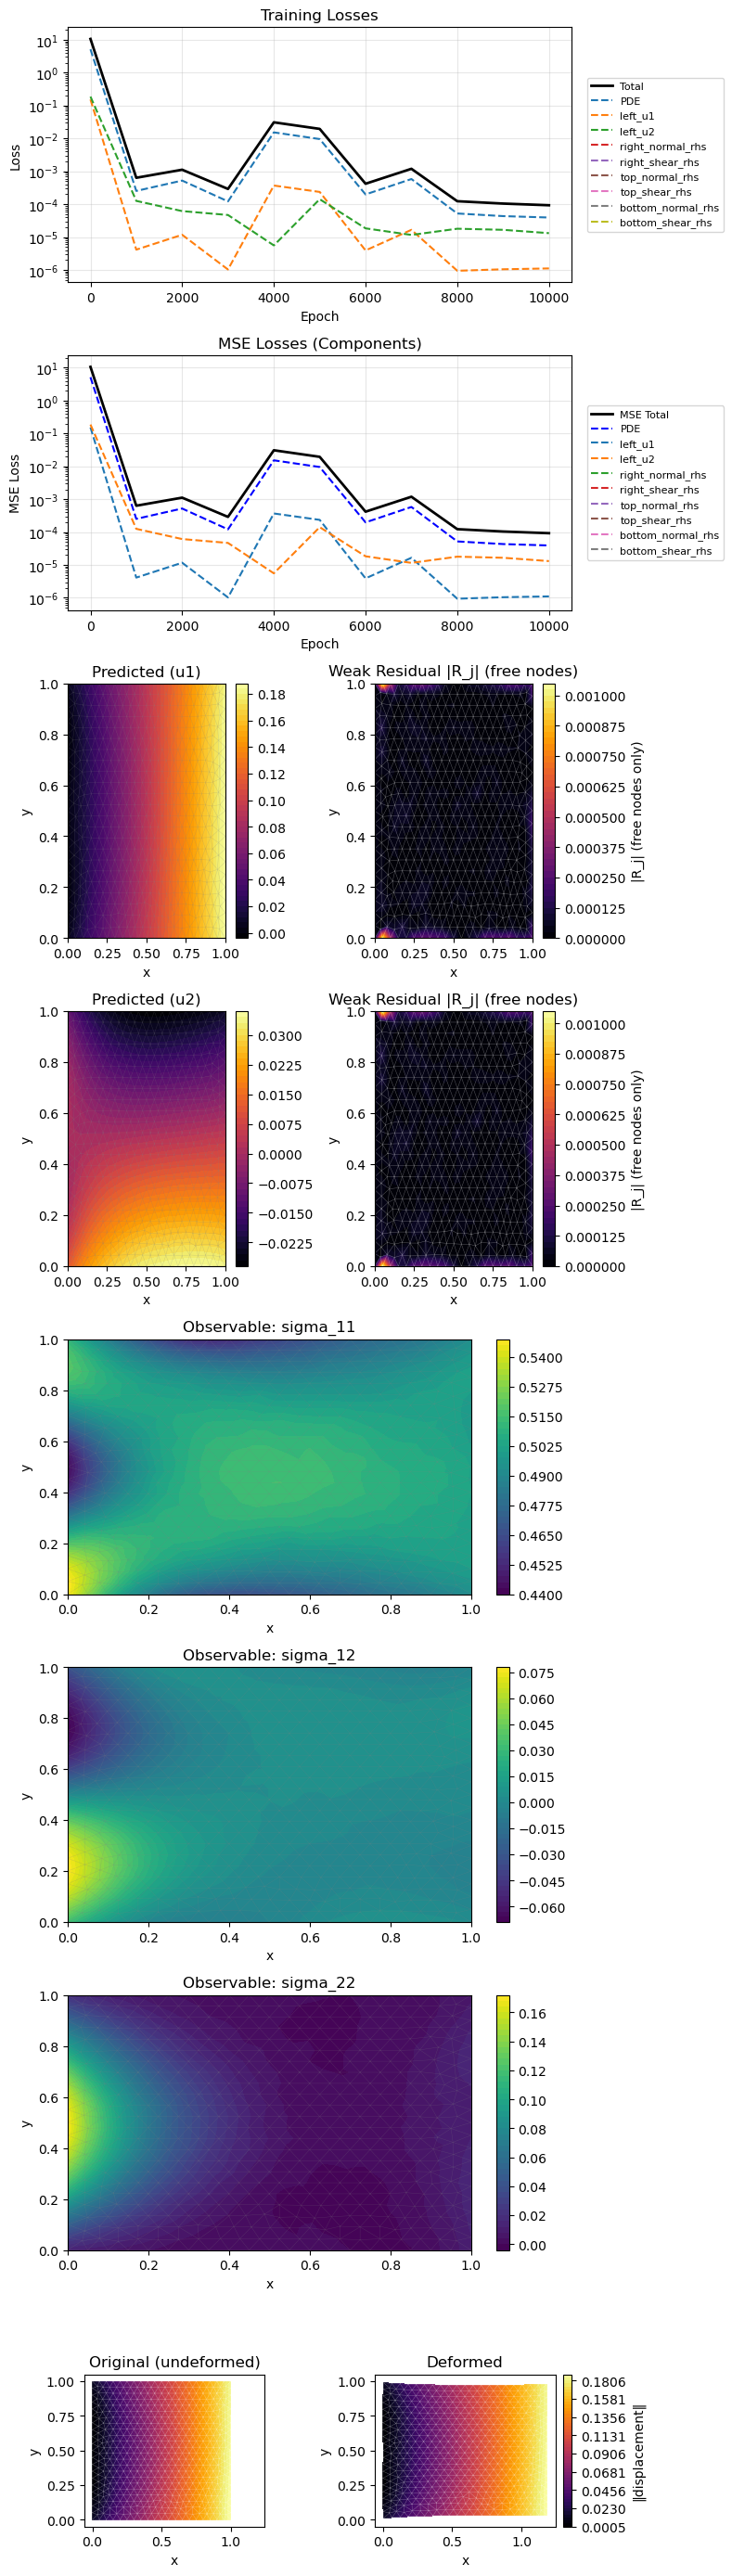

Epoch 0/10000 | Loss: 1.07e+01 | MSE Loss: 1.07e+01 | PDE: 5.16e+00 | BCs: [left_u1: 1.53e-01, left_u2: 1.87e-01, right_normal_rhs: 0.00e+00, right_shear_rhs: 0.00e+00, top_normal_rhs: 0.00e+00, top_shear_rhs: 0.00e+00, bottom_normal_rhs: 0.00e+00, bottom_shear_rhs: 0.00e+00] | Time: 0.0s
Epoch 1000/10000 | Loss: 6.35e-04 | MSE Loss: 6.35e-04 | PDE: 2.53e-04 | BCs: [left_u1: 4.13e-06, left_u2: 1.26e-04, right_normal_rhs: 0.00e+00, right_shear_rhs: 0.00e+00, top_normal_rhs: 0.00e+00, top_shear_rhs: 0.00e+00, bottom_normal_rhs: 0.00e+00, bottom_shear_rhs: 0.00e+00] | Time: 3.9s
Epoch 2000/10000 | Loss: 1.12e-03 | MSE Loss: 1.12e-03 | PDE: 5.22e-04 | BCs: [left_u1: 1.17e-05, left_u2: 6.15e-05, right_normal_rhs: 0.00e+00, right_shear_rhs: 0.00e+00, top_normal_rhs: 0.00e+00, top_shear_rhs: 0.00e+00, bottom_normal_rhs: 0.00e+00, bottom_shear_rhs: 0.00e+00] | Time: 5.1s
Epoch 3000/10000 | Loss: 2.91e-04 | MSE Loss: 2.91e-04 | PDE: 1.21e-04 | BCs: [left_u1: 1.03e-06, left_u2: 4.68e-05, right_n

In [ ]:
network_w = pinns.FNN([2, 64, 64, 64, 2], activation="tanh")

trainer_w = pinns.Trainer(problem_w, network_w)
trainer_w.compile(
    weights={
        "pde":               1.0,  # Galerkin residual — scales the entire weak-form loss
        "left_u1":           1.0,
        "left_u2":           1.0,
        "right_normal_rhs":  1.0,
        "right_shear_rhs":   1.0,
        "top_normal_rhs":    1.0,
        "top_shear_rhs":     1.0,
        "bottom_normal_rhs": 1.0,
        "bottom_shear_rhs":  1.0,
    },
    optimizer="adam",
    learning_rate=1e-3,
    epochs=10000,
    print_each=1000,
    show_plots=True,
)
trainer_w.train()